В това упражнение ще правим линейна регресия като изпозлваме библиотеката statsmodels. Първо имаме една клетка, в която стоят всички импорти:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import seaborn as sb # библиотека за чертаене на по-сложни графики. Използва matplotlib
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.graphics.gofplots import qqplot
import itertools

## Свирене на щурци спрямо температурата
Ще разгледаме данните мощността на свирукането на щурци спрямо температурата. Първо зареждаме данните:

In [3]:
df = pd.read_excel('data/slr02.xls', engine = "xlrd")

*** No CODEPAGE record, no encoding_override: will use 'iso-8859-1'


In [4]:
df

,X,Y
0,20.000000,88.599998
1,16.000000,71.599998
2,19.799999,93.300003
3,18.400000,84.300003
4,17.100000,80.599998
5,15.500000,75.199997
6,14.700000,69.699997
7,17.100000,82.000000
8,15.400000,69.400002
9,16.200001,83.300003


In [5]:
df.columns = ['temp', 'noise']

In [6]:
df.shape

(15, 2)

Ще зползваме ols модела от [statsmodels](https://www.statsmodels.org/dev/index.html). Библиотеката statsmodels имплементира редица статистически модели. Ако изпозлваме обикновената имплементация на Ordinary Least Squares ([statsmodels.regression.linear_model.OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)]), подаваме данните като x и y аргументите на ols функцията. Ние ще изпозлваме имплементацията от [statsmodels.formula.api](https://www.statsmodels.org/dev/example_formulas.html), която ни позволява да зададем модела по подобен на R начин - като подадем формула за модел като string.

In [7]:
model = ols(formula='noise ~ temp', data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  noise   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     29.97
Date:                Thu, 20 Aug 2026   Prob (F-statistic):           0.000107
Time:                        11:20:46   Log-Likelihood:                -40.348
No. Observations:                  15   AIC:                             84.70
Df Residuals:                      13   BIC:                             86.11
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.2323     10.060      2.508      0.026       3.499      46.966
temp           3.2911      0.601      5.475      0.000       1.992       4.590
==============================================================================
Omnibus:                        1.003   Durbin-Watson:                   1.818
Prob(Omnibus):                  0.606   Jarque-Bera (JB):                0.874
Skew:                          -0.391   Prob(JB):                        0.646
Kurtosis:                       2.114   Cond. No.                         171.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

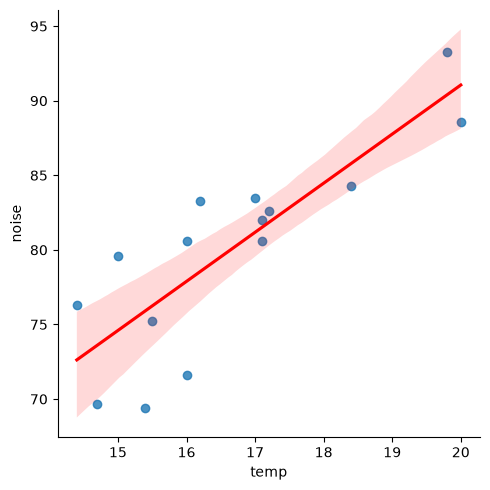

In [8]:
sb.lmplot(x='temp', y='noise', data=df, line_kws = {'color': 'red'})

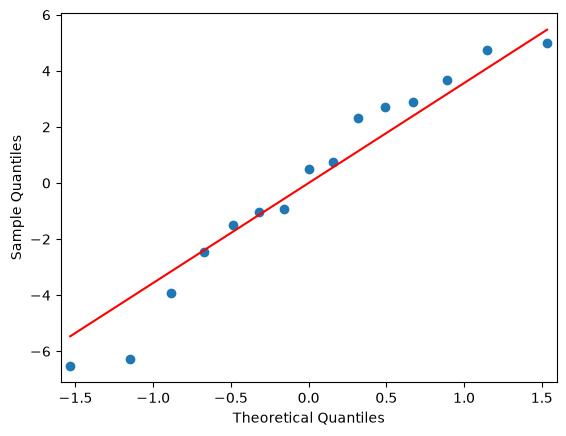

In [9]:
plot = qqplot(model.resid, line='s') # line='s' означава, че ще се изчертае права линия, която е най-добро приближение на теоретичната крива на нормалното разпределение за дадените данни

## Качество на червени вина

Файлът winequality-red.csv съдържа данни за редица характеристикина червени вина и оценка за виното от 1 до 10. Ще разгледаме дали как се справя модел на линейна регресия с тези данни.

In [10]:
df = pd.read_csv('data/winequality_red.csv', sep=';')

In [11]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Понеже ще използваме формули за модела в стил R, трябва да нямаме спейсове в имената на колоните

In [12]:
df.columns = [c.replace(' ', '_') for c in df.columns]
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

Можем да видим хистограма на точките

<Axes: >

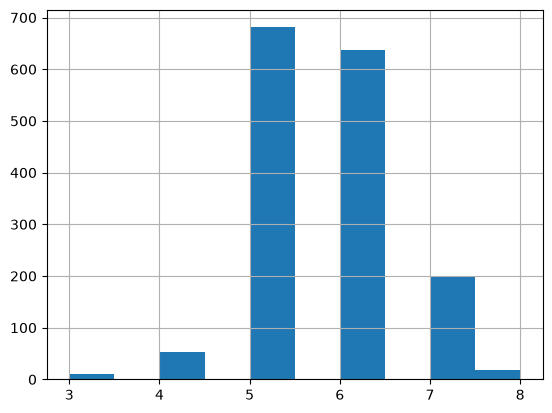

In [13]:
df.quality.astype('category').hist()

Понеже точките са числа, pandas не се сеща да подреди превилно биновете. Трябва да направим малко numpy магия, ако искаме графиката да е добре центрирана:

<Axes: ylabel='Frequency'>

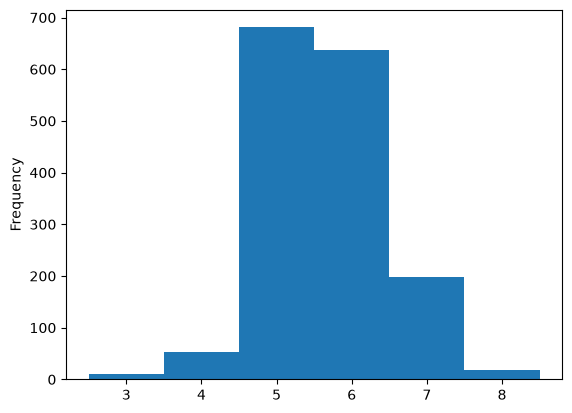

In [14]:
bins = np.arange(min(df.quality), max(df.quality) + 1.5) - 0.5 # биновете за 3 трябва да са 2.5 и 3.5 и ни трябва  един повече бин отколкото стойности имаме за точките
df.quality.plot.hist(bins=bins)

## Задача 1

Пресметнете средните, минималните и максималните стойности на променливите и ковариационната матрица. Имаме ли зависимости между предикторите? Има ли нужда да нормализираме променливите?

In [15]:
# Средни, минимални и максимални стойности
df.agg(['mean', 'min', 'max'])

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [16]:
# Koвариационна матрица
df.cov()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
fixed_acidity,3.031416,-0.079851,0.227820,0.281756,0.007679,-2.800921,-6.482346,0.002195,-0.183586,0.054010,-0.114421,0.174424
volatile_acidity,-0.079851,0.032062,-0.019272,0.000484,0.000517,-0.019674,0.450426,0.000007,0.006495,-0.007921,-0.038600,-0.056476
citric_acid,0.227820,-0.019272,0.037947,0.039434,0.001869,-0.124252,0.227697,0.000134,-0.016298,0.010328,0.022815,0.035612
residual_sugar,0.281756,0.000484,0.039434,1.987897,0.003690,2.758611,9.416441,0.000945,-0.018644,0.001321,0.063219,0.015635
chlorides,0.007679,0.000517,0.001869,0.003690,0.002215,0.002738,0.073387,0.000018,-0.001926,0.002962,-0.011092,-0.004900
free_sulfur_dioxide,-2.800921,-0.019674,-0.124252,2.758611,0.002738,109.414884,229.737521,-0.000433,0.113653,0.091592,-0.773698,-0.427907
total_sulfur_dioxide,-6.482346,0.450426,0.227697,9.416441,0.073387,229.737521,1082.102373,0.004425,-0.337699,0.239471,-7.209298,-4.917237
density,0.002195,0.000007,0.000134,0.000945,0.000018,-0.000433,0.004425,0.000004,-0.000100,0.000048,-0.000998,-0.000267
pH,-0.183586,0.006495,-0.016298,-0.018644,-0.001926,0.113653,-0.337699,-0.000100,0.023835,-0.005146,0.033832,-0.007198
sulphates,0.054010,-0.007921,0.010328,0.001321,0.002962,0.091592,0.239471,0.000048,-0.005146,0.028733,0.016907,0.034413


<Axes: >

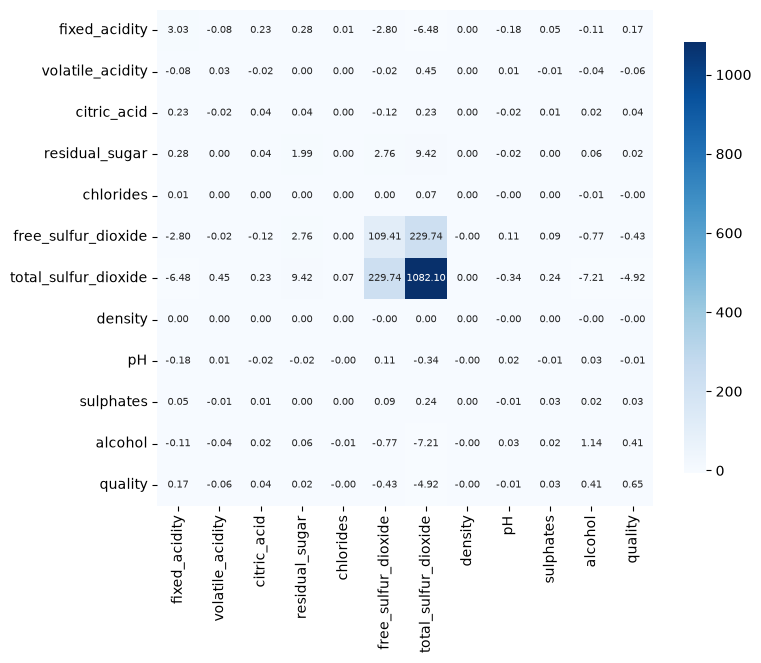

In [17]:
# За да видим визуално зависимостите може да използваме топлинен плот
plt.figure(figsize=(8,8))
sb.heatmap(df.cov(), annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

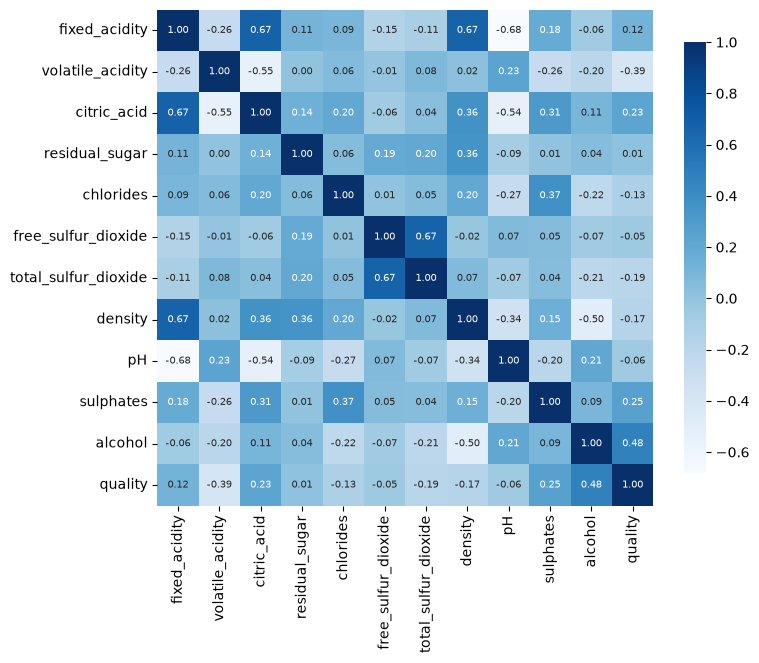

In [18]:
# Забележете, че някои стойности са много малки, а други много големи. Това е защото ковариацията между две променливи зависи от мащаба и мерните единици.
# Toест, ковариацията на две променливи в диапазона [0, 1] ще е много по-малка от ковариацията на две променливи в диапазона [0, 1000]. Това прави трудно сравняването на ковариационните коефициенти.
# За да можем да сравним ковариацията на две променливи с различен мащаб първо ще ги стандартизираме.
df_standardized = (df - df.mean()) / df.std()

plt.figure(figsize=(8,8))
sb.heatmap(df_standardized.cov(), annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

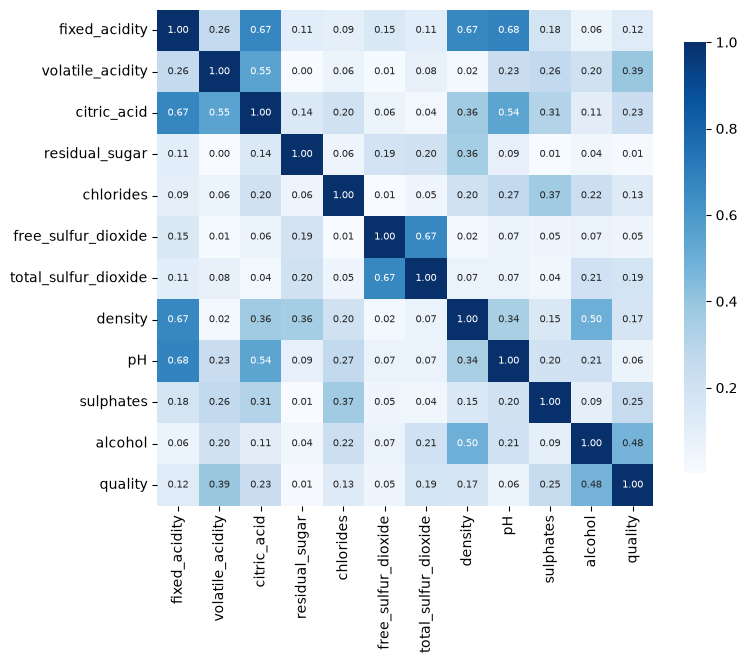

In [19]:
# За да отговорим на въпроса дали има зависимости, можем да използваме само абсолютната стойност на ковариацията. Така по ясно ще видим между кои променливи имат по-голяма зависимост:
cov = np.abs(df_standardized.cov())

plt.figure(figsize=(8, 8))
sb.heatmap(cov, annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

<Axes: >

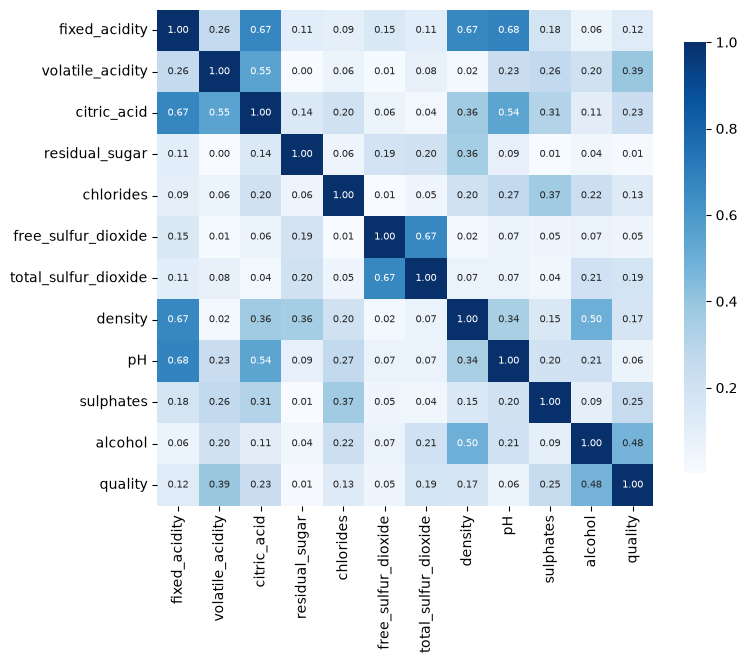

In [20]:
# Забележете, че в случая можехме да използваме и корелационната матрица с оригиналните данни, която е нормализираната ковариационна матрица.
corr = np.abs(df.corr())

plt.figure(figsize=(8, 8))
sb.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', square=True, cbar_kws={'shrink': .7}, annot_kws={'size': 7})

In [21]:
# Ако изберем за граница на зависимост 0.3, то ще получим следните двойки променливи:
corr = corr.mask(np.triu(np.ones(corr.shape, dtype=bool)), 0) # Mаскираме диагонала и горния триъгълник на матрицата, за да не се повтарят двойките променливи

stack = corr.stack()

stack[stack > 0.3] \
    .reset_index() \
    .rename(columns={'level_0': 'predictor 1', 'level_1': 'predictor 2', 0: 'correlation'}) \
    .sort_values(by='correlation', ascending=False) \
    .reset_index(drop=True) 

,predictor 1,predictor 2,correlation
0,pH,fixed_acidity,0.682978
1,citric_acid,fixed_acidity,0.671703
2,density,fixed_acidity,0.668047
3,total_sulfur_dioxide,free_sulfur_dioxide,0.667666
4,citric_acid,volatile_acidity,0.552496
5,pH,citric_acid,0.541904
6,alcohol,density,0.496180
7,quality,alcohol,0.476166
8,quality,volatile_acidity,0.390558
9,sulphates,chlorides,0.371260


## Задача 2
Скалирайте данните в интервала [0, +1].

In [22]:
scaled_df = df.copy()

mins = scaled_df.min()
maxs = scaled_df.max()

scaled_df = (scaled_df - mins) / (maxs - mins)

scaled_df.agg(['mean', 'min', 'max'])

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
mean,0.329171,0.279329,0.270976,0.112247,0.125988,0.209506,0.142996,0.490211,0.449695,0.196496,0.311228,0.527205
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Задача 3
Изградете линеен модел на регресия, използващ всички предиктори. Анализирайте резултата. Можем ли да премахнем някои предиктори от модела? Тествайте грешките на модела за нормалност.

Тук може да използваме възможността на манипулация на стрингове на python за да изградим тази формула без да трябва да пишем всички колони на таблицата на ръка.

In [23]:
def formula(target, variables):
    predictors = [v for v in variables if v != target]
    return f'{target} ~ {' + '.join(predictors)}'

Получаваме $Adj. \ R^2 = 0.356$ което е много ниско. Голяма част от коефициентите на предикторите са сигнификанти на нивото $0.05$.

In [24]:
model = ols(formula=formula('quality', df.columns), data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.361
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     81.35
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          1.79e-145
Time:                        11:20:53   Log-Likelihood:                -1569.1
No. Observations:                1599   AIC:                             3162.
Df Residuals:                    1587   BIC:                             3227.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               21.9652     21.195      1.036      0.300     -19.607      63.538
fixed_acidity            0.0250      0.026      0.963      0.336      -0.026       0.076
volatile_acidity        -1.0836      0.121     -8.948      0.000      -1.321      -0.846
citric_acid             -0.1826      0.147     -1.240      0.215      -0.471       0.106
residual_sugar           0.0163      0.015      1.089      0.276      -0.013       0.046
chlorides               -1.8742      0.419     -4.470      0.000      -2.697      -1.052
free_sulfur_dioxide      0.0044      0.002      2.009      0.045       0.000       0.009
total_sulfur_dioxide    -0.0033      0.001     -4.480      0.000      -0.005      -0.002
density                -17.8812     21.633     -0.827      0.409     -60.314      24.551
pH                      -0.4137      0.192     -2.159      0.031      -0.789      -0.038
sulphates                0.9163      0.114      8.014      0.000       0.692       1.141
alcohol                  0.2762      0.026     10.429      0.000       0.224       0.328
==============================================================================
Omnibus:                       27.376   Durbin-Watson:                   1.757
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               40.965
Skew:                          -0.168   Prob(JB):                     1.27e-09
Kurtosis:                       3.708   Cond. No.                     1.13e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.13e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Можем да опитаме да премахнем несигнификанти променливи или променливи с висока мултиколинеарност.

In [25]:
corr = corr.mask(np.triu(np.ones(corr.shape, dtype=bool)), 0) # Mаскираме диагонала и горния триъгълник на матрицата, за да не се повтарят двойките променливи

stack = corr.stack()

correlated_predictors = stack[stack > 0.5] \
    .reset_index() \
    .rename(columns={'level_0': 'predictor 1', 'level_1': 'predictor 2', 0: 'correlation'}) \
    .sort_values(by='correlation', ascending=False) \
    .reset_index(drop=True) 

correlated_predictors

,predictor 1,predictor 2,correlation
0,pH,fixed_acidity,0.682978
1,citric_acid,fixed_acidity,0.671703
2,density,fixed_acidity,0.668047
3,total_sulfur_dioxide,free_sulfur_dioxide,0.667666
4,citric_acid,volatile_acidity,0.552496
5,pH,citric_acid,0.541904


In [27]:
columns = [c for c in df.columns if c not in [
    'fixed_acidity',
]]

model = ols(formula=formula('quality', columns), data=df).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                quality   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.356
Method:                 Least Squares   F-statistic:                     89.39
Date:                Thu, 20 Aug 2026   Prob (F-statistic):          2.92e-146
Time:                        11:21:08   Log-Likelihood:                -1569.6
No. Observations:                1599   AIC:                             3161.
Df Residuals:                    1588   BIC:                             3220.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                6.1796     13.437      0.460      0.646     -20.176      32.535
volatile_acidity        -1.0778      0.121     -8.911      0.000      -1.315      -0.841
citric_acid             -0.1353      0.139     -0.975      0.330      -0.407       0.137
residual_sugar           0.0101      0.014      0.746      0.456      -0.016       0.037
chlorides               -1.9685      0.408     -4.828      0.000      -2.768      -1.169
free_sulfur_dioxide      0.0046      0.002      2.128      0.034       0.000       0.009
total_sulfur_dioxide    -0.0034      0.001     -4.835      0.000      -0.005      -0.002
density                 -1.5167     13.389     -0.113      0.910     -27.779      24.745
pH                      -0.5462      0.133     -4.099      0.000      -0.808      -0.285
sulphates                0.8996      0.113      7.961      0.000       0.678       1.121
alcohol                  0.2901      0.022     13.047      0.000       0.246       0.334
==============================================================================
Omnibus:                       25.101   Durbin-Watson:                   1.752
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.849
Skew:                          -0.159   Prob(JB):                     9.96e-09
Kurtosis:                       3.672   Cond. No.                     7.04e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.04e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Задача 4 *

Постройте всички възможни комбинации от предиктори и съответващите им модели. Намерете най-добрия модел само от гледна точка на squared sum of residuals. Намерете най-добрия модел само от гледна точка на adjusted R^2. По-добри ли са тези модели от ръчно избрания?

Можем да изпозлваме функцията [combinations](https://docs.python.org/3/library/itertools.html#itertools.combinations) от вградената библиотека itertools, за да генерираме всички комбинации с k елемента от един масив.